## **Tech Challenge 2**



1) Importação de biblioteca e Instanciamento do Dataset

In [54]:
import matplotlib.pyplot as plt
import random
import numpy as np
import seaborn as sns
import pandas as pd


In [55]:
df = pd.read_csv('/content/WineQT.csv', encoding='utf-8')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [56]:
# Resumo completo de valores faltantes
print(df.info())

# Contar valores faltantes totais
print(df.isnull().sum().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
0


In [57]:
# Verificação de duplicidade
df.duplicated().sum()

np.int64(0)

In [58]:
# Verificação de missing data
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [59]:
df_null = df.isnull().sum().sum()
if df_null==0:
  print('Não há missing data')
else:
  print('Há missing data')

Não há missing data


In [60]:
# Descrição das primcipais estatísticas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


2) Análise Exploraória dos Dados

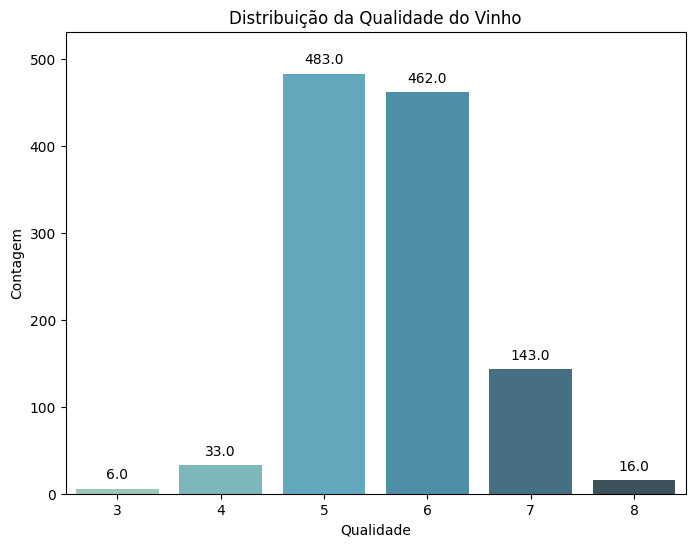

In [61]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='quality', data=df, palette='GnBu_d')
plt.title('Distribuição da Qualidade do Vinho')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')

# Adicionar labels no topo das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Ajustar o limite superior do eixo y para acomodar os labels
max_height = df['quality'].value_counts().max()
ax.set_ylim(0, max_height * 1.1)

plt.show()

2.1 Entendimento das features dos vinhos

In [62]:
wine_variables = {
    'fixed_acidity': {
        'type': 'lower_better',
        'ideal_range': (5.0, 8.0),
        'impact_excess': 'Aumenta acidez, pode tornar o vinho muito ácido',
        'unit': 'g/dm³'
    },
    'volatile_acidity': {
        'type': 'lower_better',
        'ideal_range': (0.2, 0.6),
        'impact_excess': 'Odor de vinagre, sabor desagradável',
        'unit': 'g/dm³'
    },
    'citric_acid': {
        'type': 'optimal',
        'ideal_range': (0.2, 0.5),
        'impact_excess': 'Pode causar acidez excessiva',
        'unit': 'g/dm³'
    },
    'residual_sugar': {
        'type': 'lower_better',
        'ideal_range': (1.0, 3.0),
        'impact_excess': 'Doçura excessiva e menor teor alcoólico',
        'unit': 'g/dm³'
    },
    'chlorides': {
        'type': 'lower_better',
        'ideal_range': (0.01, 0.08),
        'impact_excess': 'Sabor salgado',
        'unit': 'g/dm³'
    },
    'free_sulfur_dioxide': {
        'type': 'optimal',
        'ideal_range': (10, 40),
        'impact_excess': 'Odor irritante, sabor metálico',
        'unit': 'mg/dm³'
    },
    'total_sulfur_dioxide': {
        'type': 'lower_better',
        'ideal_range': (50, 150),
        'impact_excess': 'Odor forte, possível reação alérgica',
        'unit': 'mg/dm³'
    },
    'density': {
        'type': 'optimal',
        'ideal_range': (0.990, 1.005),
        'impact_excess': 'Menor teor alcoólico ou maior doçura',
        'unit': 'g/cm³'
    },
    'pH': {
        'type': 'optimal',
        'ideal_range': (3.0, 3.6),
        'impact_excess': 'Muito baixo: acidez extrema; muito alto: instabilidade',
        'unit': ''
    },
    'sulphates': {
        'type': 'higher_better',
        'ideal_range': (0.5, 1.0),
        'impact_excess': 'Sabor amargo e adstringente',
        'unit': 'g/dm³'
    },
    'alcohol': {
        'type': 'higher_better',
        'ideal_range': (9.0, 14.0),
        'impact_excess': 'Sabor alcoólico forte, corpo pesado',
        'unit': '% vol'
    },
    'quality': {
        'type': 'target',
        'ideal_range': (7, 8),
        'impact_excess': 'N/A',
        'unit': 'pontuação (0-10)'
    }
}

# Exemplos de uso:
# Acessar informações de uma variável específica
var_name = 'alcohol'
if var_name in wine_variables:
    info = wine_variables[var_name]
    print(f'Variável: {var_name}')
    print(f'Tipo: {info["type"]}')
    print(f'Intervalo ideal: {info["ideal_range"]}')
    print(f'Impacto do excesso: {info["impact_excess"]}')
    print(f'Unidade: {info["unit"]}')

# Iterar sobre todas as variáveis
print('\nTodas as variáveis:')
for var, info in wine_variables.items():
    print(f'{var}: {info["type"]}, ideal: {info["ideal_range"]}')

Variável: alcohol
Tipo: higher_better
Intervalo ideal: (9.0, 14.0)
Impacto do excesso: Sabor alcoólico forte, corpo pesado
Unidade: % vol

Todas as variáveis:
fixed_acidity: lower_better, ideal: (5.0, 8.0)
volatile_acidity: lower_better, ideal: (0.2, 0.6)
citric_acid: optimal, ideal: (0.2, 0.5)
residual_sugar: lower_better, ideal: (1.0, 3.0)
chlorides: lower_better, ideal: (0.01, 0.08)
free_sulfur_dioxide: optimal, ideal: (10, 40)
total_sulfur_dioxide: lower_better, ideal: (50, 150)
density: optimal, ideal: (0.99, 1.005)
pH: optimal, ideal: (3.0, 3.6)
sulphates: higher_better, ideal: (0.5, 1.0)
alcohol: higher_better, ideal: (9.0, 14.0)
quality: target, ideal: (7, 8)


In [63]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


2.2 Box-Plot

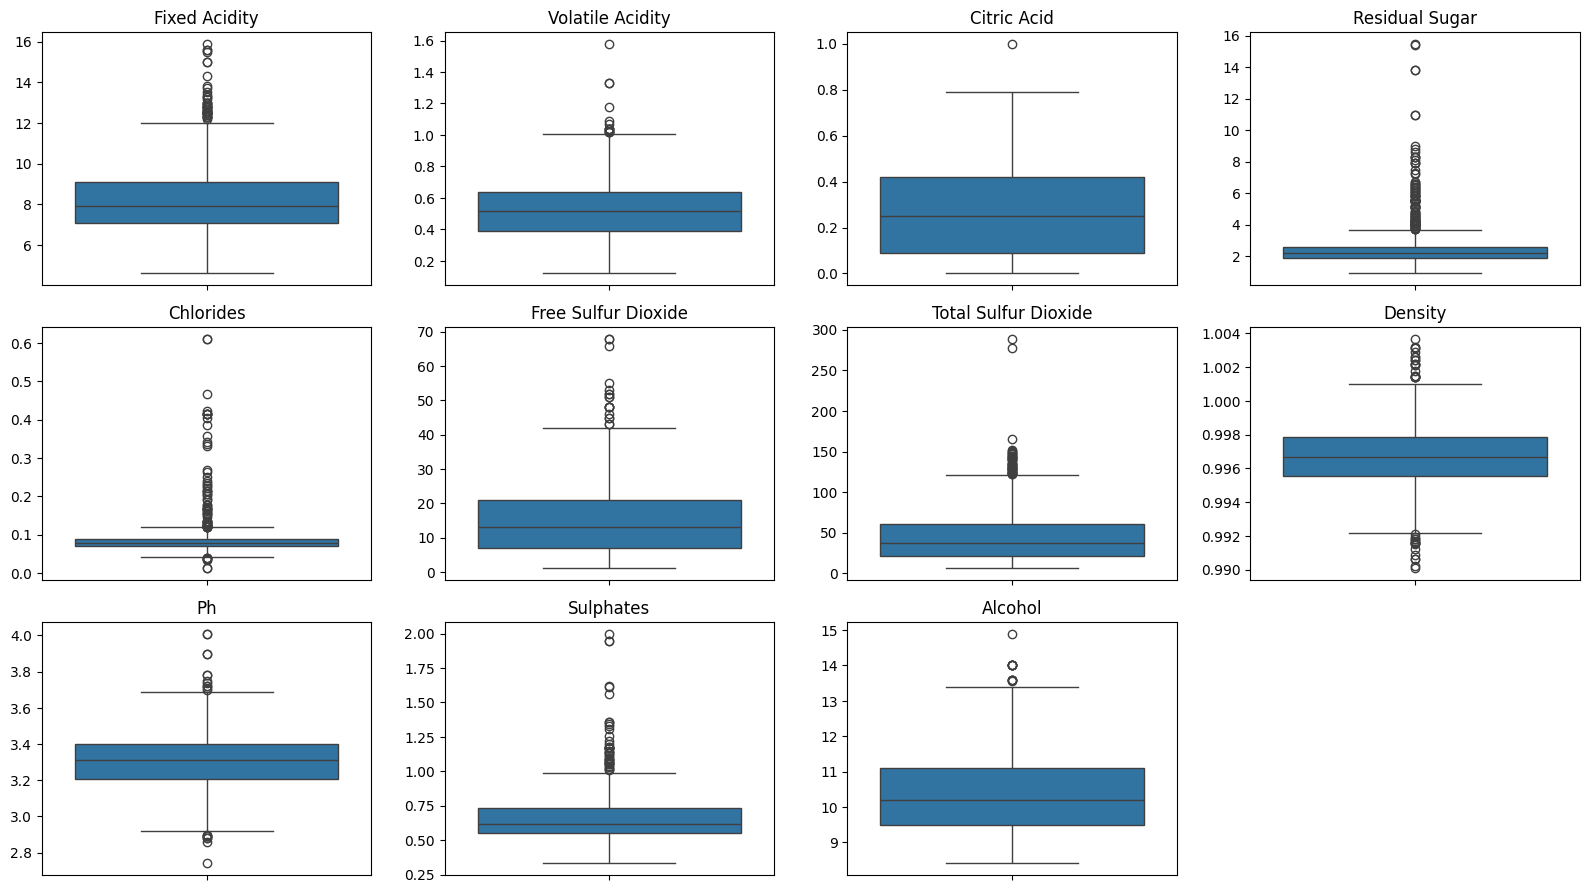

In [64]:
# Visualização Boxplot

features_to_plot = df.drop(columns=['Id', 'quality'], errors='ignore').columns.tolist()
# Explicitly remove 'quality_binary' if it exists, for robustness


num_features = len(features_to_plot)
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed for 11 features

plt.figure(figsize=(num_cols * 4, num_rows * 3)) # Adjust figure size for better readability

for i, col in enumerate(features_to_plot):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col.replace("_", " ").title()}')
    plt.ylabel('') # Remove y-label as title is descriptive

plt.tight_layout()
plt.show()

2.3 Distribuição

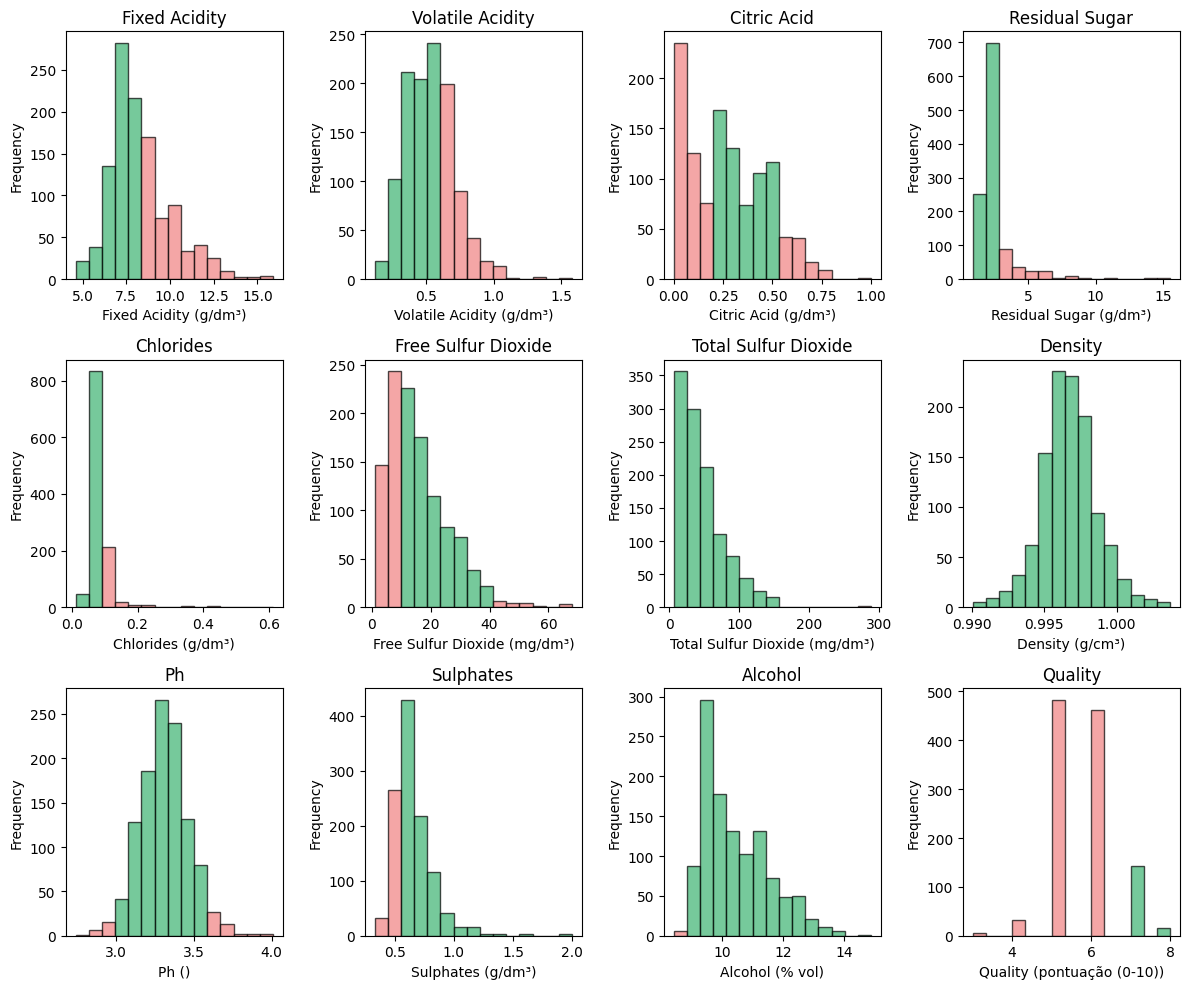

In [65]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df and wine_variables are available from previous cells

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')

num_rows = 3
num_cols_per_row = 4

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(12, 10))
axes = axes.flatten()

# Define colors for ideal and non-ideal bins
color_ideal = 'mediumseagreen'
color_non_ideal = 'lightcoral'
color_default = 'skyblue' # For variables without ideal_range or type not handled

for i, col_name_with_space in enumerate(numerical_cols):
    if i < len(axes):
        ax = axes[i]

        col_name_underscore = col_name_with_space.replace(' ', '_')
        var_info = wine_variables.get(col_name_underscore, {}) # Get info for the current variable
        ideal_range = var_info.get('ideal_range')
        var_type = var_info.get('type')
        unit = var_info.get('unit', '')

        # Get histogram data
        counts, bin_edges, patches = ax.hist(df[col_name_with_space], bins=15, edgecolor='black', alpha=0.7)

        if ideal_range:
            for patch, left_edge, right_edge in zip(patches, bin_edges[:-1], bin_edges[1:]):
                bin_center = (left_edge + right_edge) / 2

                current_color = color_non_ideal

                if var_type == 'optimal':
                    if ideal_range[0] <= bin_center <= ideal_range[1]:
                        current_color = color_ideal
                elif var_type == 'lower_better':
                    if bin_center <= ideal_range[1]: # Assuming ideal_range[1] is the upper limit for "good" values
                        current_color = color_ideal
                elif var_type == 'higher_better':
                    if bin_center >= ideal_range[0]: # Assuming ideal_range[0] is the lower limit for "good" values
                        current_color = color_ideal
                elif var_type == 'target': # Added specific handling for 'target' type like 'quality'
                    if ideal_range[0] <= bin_center <= ideal_range[1]:
                        current_color = color_ideal
                # For unrecognized types, it remains color_non_ideal unless explicitly set.

                patch.set_facecolor(current_color)
        else:
            # If no ideal_range is defined, use a default color for all bins
            for patch in patches:
                patch.set_facecolor(color_default)

        ax.set_title(col_name_with_space.replace("_", " ").title())
        ax.set_xlabel(f"{col_name_with_space.replace('_', ' ').title()} ({unit})")
        ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

2.4 Análise de Correlação entre as features - Matriz de Correlação

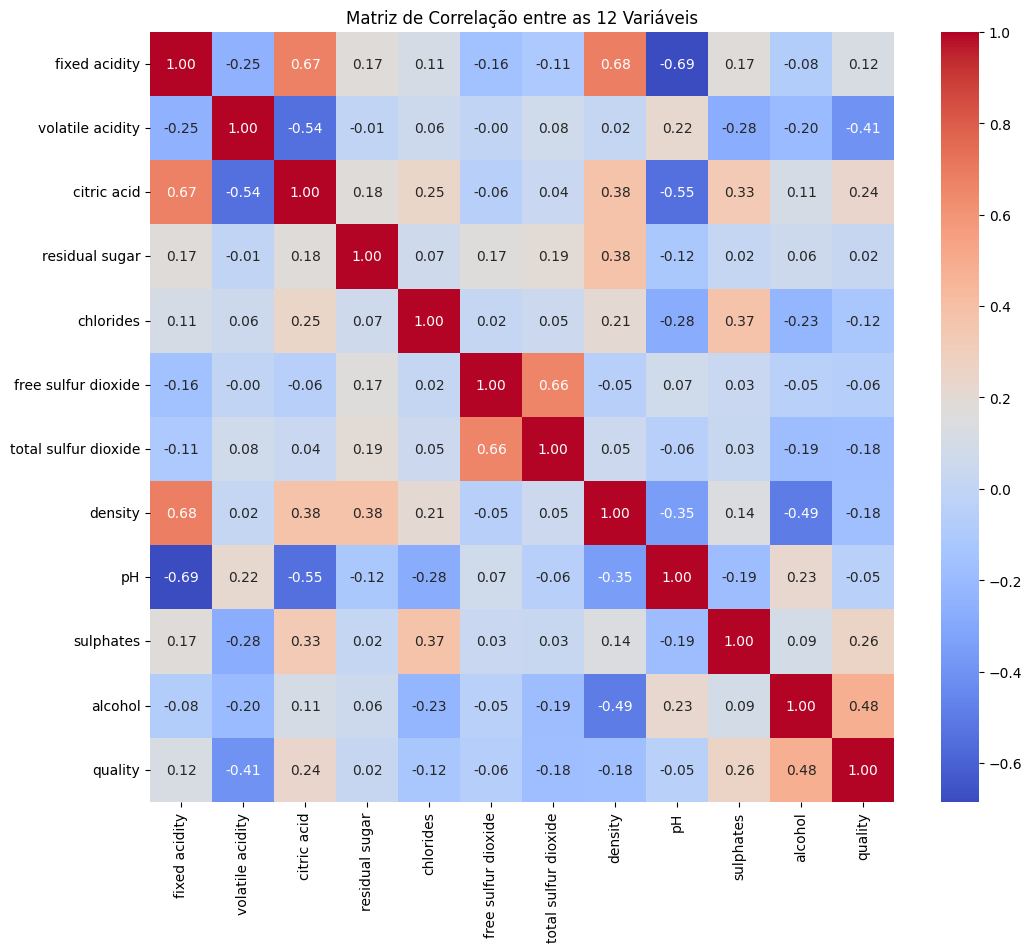

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exclude 'Id' column as it's not a feature for correlation
correlation_df = df.drop(columns=['Id'])

# Calculate the correlation matrix
corr_matrix = correlation_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre as 12 Variáveis')
plt.show()

2.5 Análise de Correlação entre as features - Scatter Plot

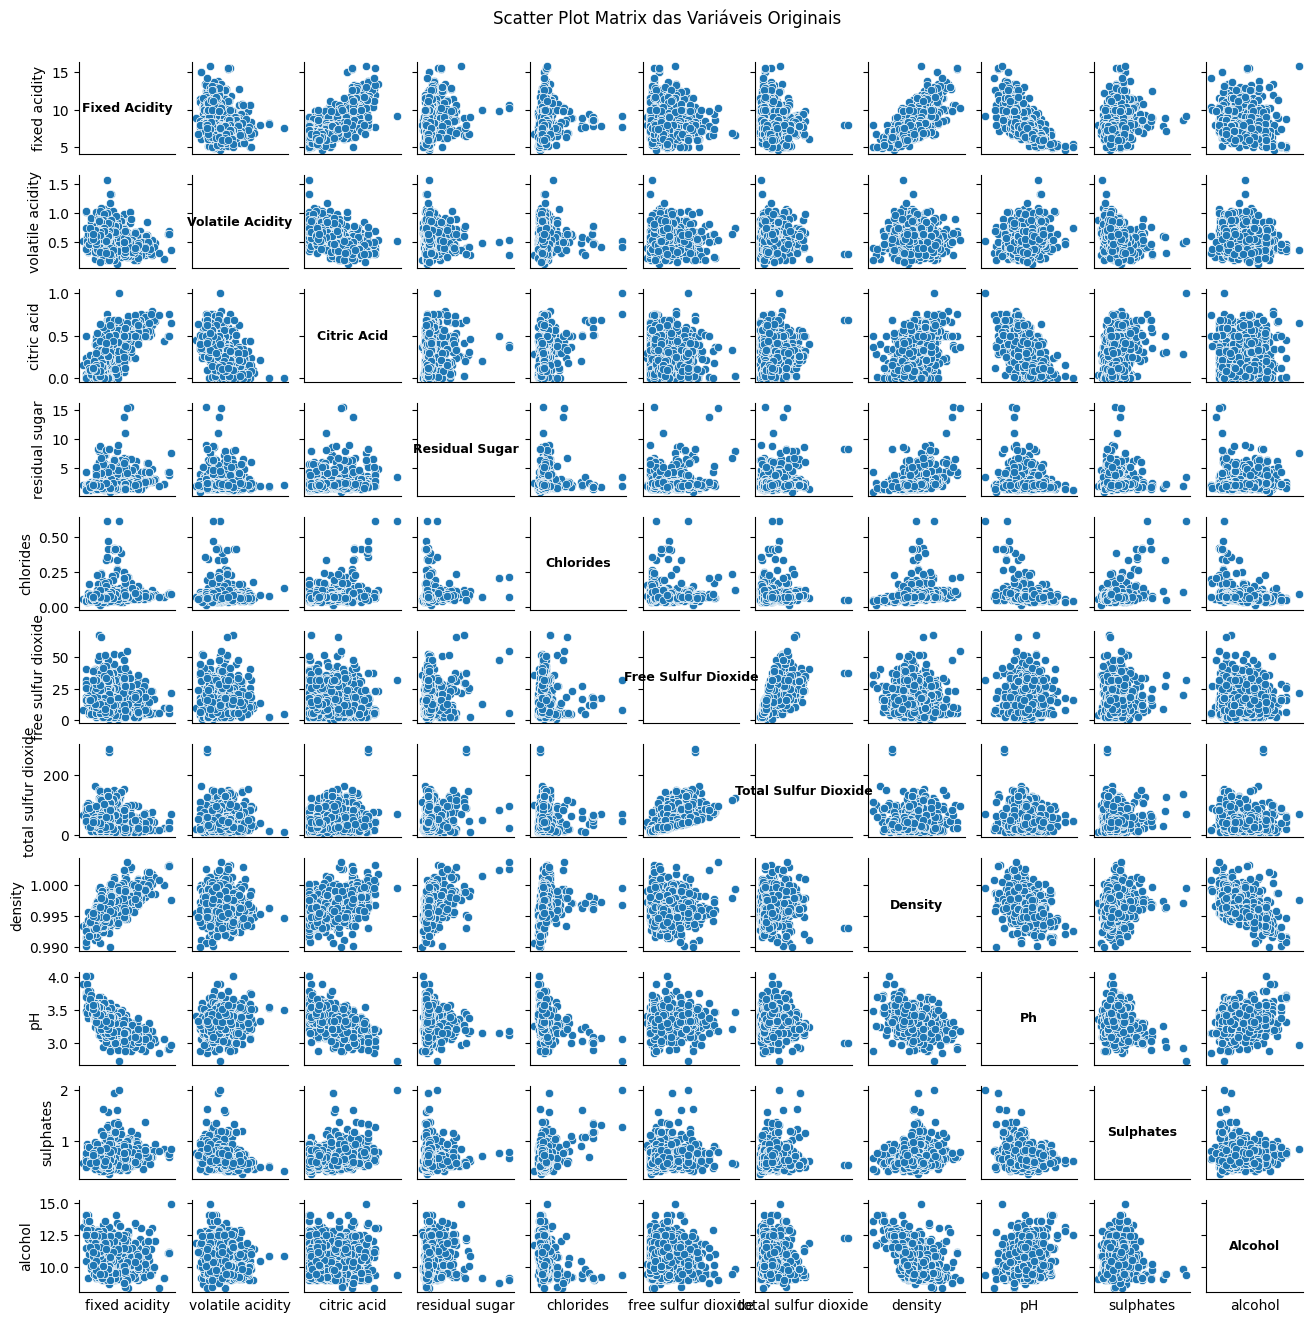

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the non-standardized features from the 'X' DataFrame
pairplot_df = X

# Initialize PairGrid for more customization
g = sns.PairGrid(pairplot_df, height=1.2) # Adjust height of each facet for overall figure size

# Map scatter plots to upper and lower triangles
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

# Custom function to put feature name on diagonal
def label_diag(x, **kwargs):
    ax = plt.gca()
    ax.clear() # Clear any default plot elements (like histograms/KDEs)
    ax.set_xticks([]) # Remove x-axis ticks
    ax.set_yticks([]) # Remove y-axis ticks
    ax.set_xlabel('') # Remove x-axis label
    ax.set_ylabel('') # Remove y-axis label
    # Optional: remove spines for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add the feature name as text, formatted nicely
    ax.text(0.5, 0.5, x.name.replace('_', ' ').title(), transform=ax.transAxes,
            horizontalalignment='center', verticalalignment='center',
            fontsize=9, fontweight='bold')

# Map the custom function to the diagonal
g.map_diag(label_diag)

plt.suptitle('Scatter Plot Matrix das Variáveis Originais', y=1.02) # Adjusted title
plt.show()

Z-Score Standardization (Padronização)

In [68]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming 'X' DataFrame contains the features to be standardized (excluding 'Id', 'quality', 'quality_binary')
# 'X' is already defined from previous steps (cell e8atc-XhEuUz).

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Z-Score Standardization applied to features:")
display(X_scaled_df.head())

# You can also check the mean (should be ~0) and standard deviation (should be ~1)
print("\nMean of scaled features (should be close to 0):\n", X_scaled_df.mean())
print("\nStandard deviation of scaled features (should be close to 1):\n", X_scaled_df.std())

Z-Score Standardization applied to features:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382



Mean of scaled features (should be close to 0):
 fixed acidity          -3.729883e-16
volatile acidity        4.475860e-16
citric acid             2.486589e-17
residual sugar          1.554118e-16
chlorides               8.081413e-17
free sulfur dioxide    -5.594825e-17
total sulfur dioxide    9.946355e-17
density                 5.783805e-14
pH                     -8.454402e-16
sulphates               4.973178e-17
alcohol                -1.193563e-15
dtype: float64

Standard deviation of scaled features (should be close to 1):
 fixed acidity           1.000438
volatile acidity        1.000438
citric acid             1.000438
residual sugar          1.000438
chlorides               1.000438
free sulfur dioxide     1.000438
total sulfur dioxide    1.000438
density                 1.000438
pH                      1.000438
sulphates               1.000438
alcohol                 1.000438
dtype: float64


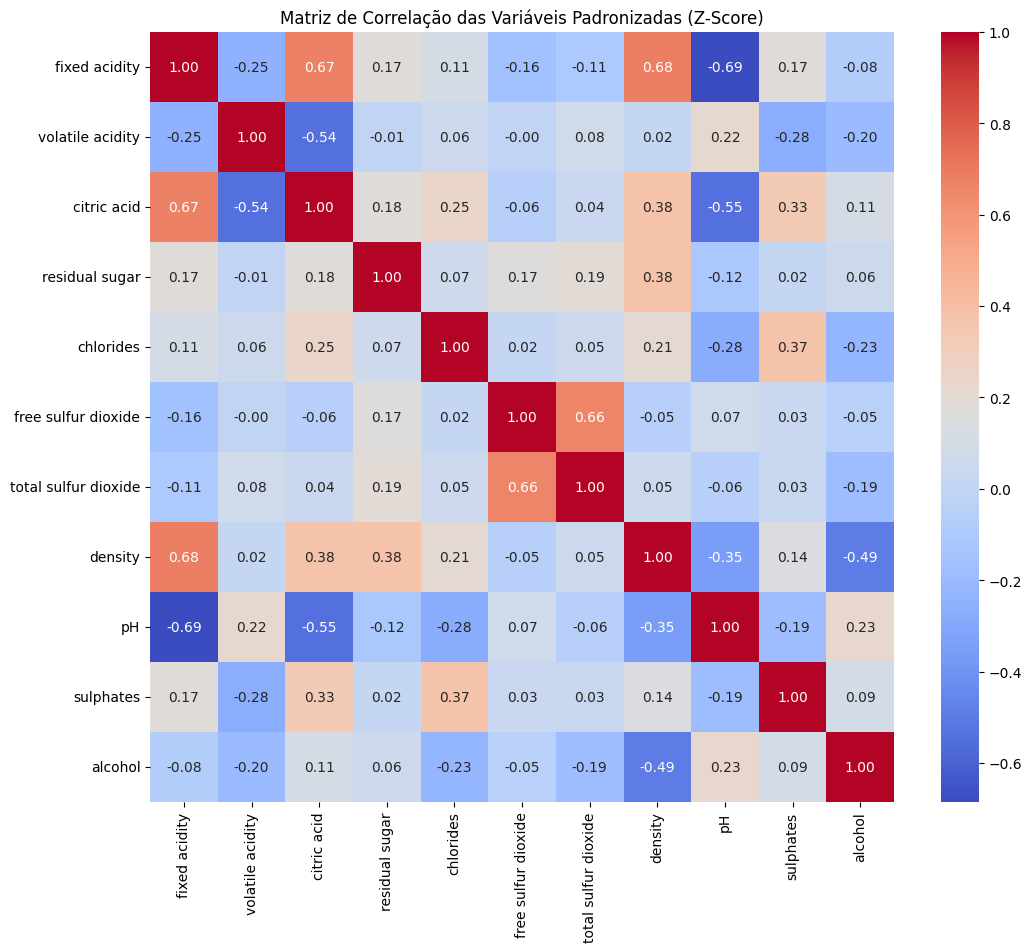

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix of the Z-Score standardized features
corr_matrix_scaled = X_scaled_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_scaled, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Padronizadas (Z-Score)')
plt.show()

Explained variance by component: [0.28692345 0.17075104]


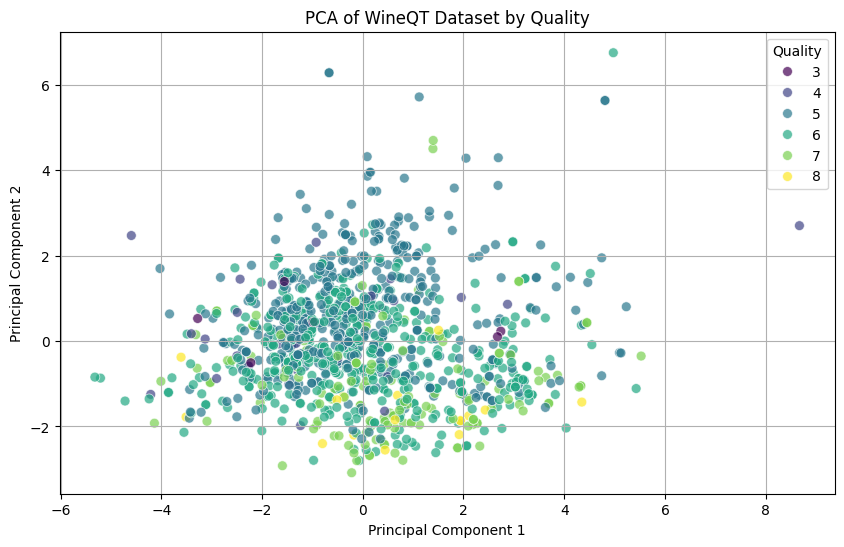

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns # Import seaborn

# Load the dataset
df = pd.read_csv('/content/WineQT.csv')

# Prepare features: exclude 'quality' and 'Id'
features = df.drop(columns=['quality', 'Id'])

# 1. Apply StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 2. Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

# 4. Calculate explained variance
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by component: {explained_variance}')

# 3. Generate Scatter Plot with Legends
plt.figure(figsize=(10, 6))

# Create a temporary DataFrame for seaborn plotting
pca_df = pd.DataFrame(data=components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Quality'] = df['quality'] # Add the original quality column for hue

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Quality', # Use 'Quality' for discrete coloring and legend
    data=pca_df,
    palette='viridis', # Keep the viridis colormap
    alpha=0.7,
    s=50 # Size of points
)

# seaborn.scatterplot automatically adds a legend when hue is used, so plt.colorbar is not needed.

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of WineQT Dataset by Quality')
plt.grid(True)
plt.show()

3. Modelagem do Machine Learning

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# (1) Carregar WineQT.csv
# Supondo que o arquivo esteja no diretório atual
df = pd.read_csv('/content/WineQT.csv')

3.1 Transformar Quality em Binário - Variável Target

Transformação concluída: quality >= 7 -> 1, < 7 -> 0


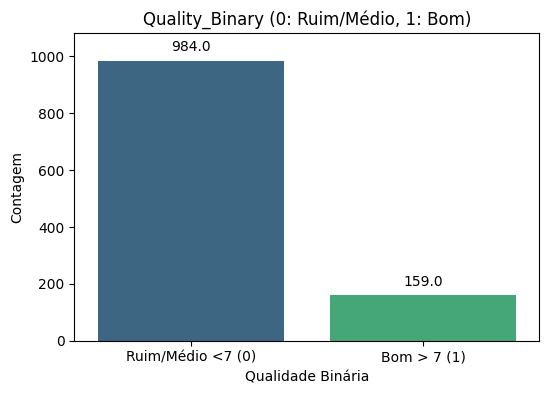

In [72]:
# (2) Transformar quality em binária IMEDIATAMENTE após carregamento
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print("Transformação concluída: quality >= 7 -> 1, < 7 -> 0")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='quality_binary', data=df, palette='viridis')
plt.title('Quality_Binary (0: Ruim/Médio, 1: Bom)')
plt.xlabel('Qualidade Binária')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Ruim/Médio <7 (0)', 'Bom > 7 (1)'])

# Adicionar labels no topo das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Ajustar o limite superior do eixo y para acomodar os labels
max_height = df['quality_binary'].value_counts().max()
ax.set_ylim(0, max_height * 1.1)

plt.show()


In [73]:
# (3) Análise exploratória (EDA) com a variável binária
print("\n--- EDA ---")
print("Primeiras linhas:")
display(df.head())




--- EDA ---
Primeiras linhas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [74]:
print("\nEstatísticas descritivas (separadas por classe):")
display(df.groupby('quality_binary').describe().T)


Estatísticas descritivas (separadas por classe):


quality_binary                 0            1
fixed acidity count   984.000000   159.000000
              mean      8.224593     8.846541
              std       1.669548     2.097038
              min       4.600000     4.900000
              25%       7.100000     7.400000
...                          ...          ...
Id            min       0.000000     7.000000
              25%     399.750000   443.000000
              50%     770.500000   941.000000
              75%    1238.250000  1100.000000
              max    1597.000000  1584.000000

[104 rows x 2 columns]


Correlações das Features com Quality (para Quality_Binary = 0 - Ruim/Médio):
alcohol                 0.325875
sulphates               0.167735
citric acid             0.092500
fixed acidity           0.055806
pH                      0.007966
free sulfur dioxide    -0.027856
residual sugar         -0.036548
chlorides              -0.072255
density                -0.106263
total sulfur dioxide   -0.158581
volatile acidity       -0.306176
Name: quality, dtype: float64


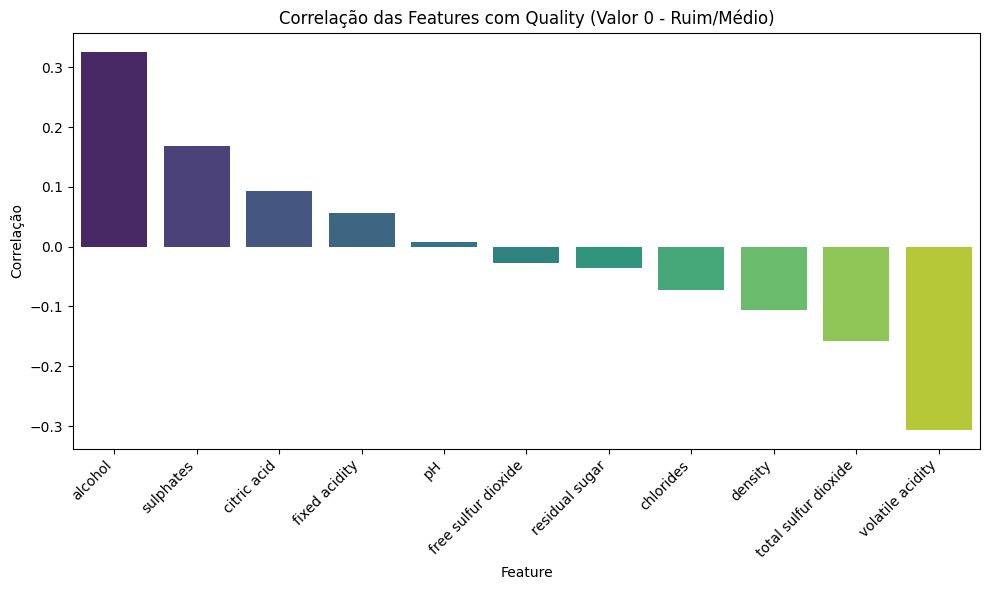


Correlações das Features com Quality (para Quality_Binary = 1 - Bom):
alcohol                 0.136189
citric acid             0.071035
sulphates               0.048393
volatile acidity        0.036537
fixed acidity          -0.006447
residual sugar         -0.025075
chlorides              -0.052061
density                -0.068440
total sulfur dioxide   -0.068763
pH                     -0.089800
free sulfur dioxide    -0.105925
Name: quality, dtype: float64


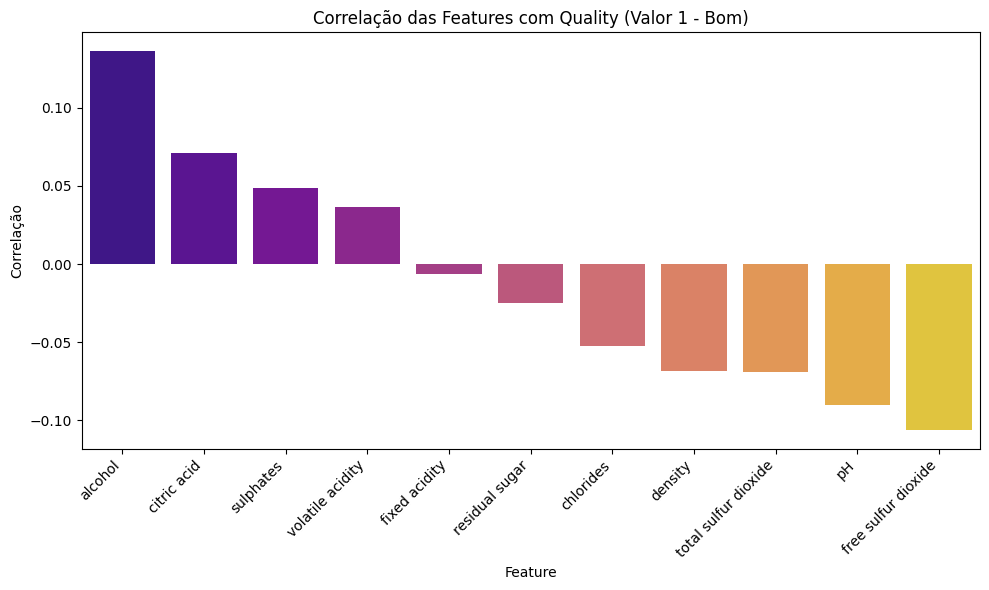

In [75]:
# Correlação com a variável alvo para quality_binary = 0
df_quality_0 = df[df['quality_binary'] == 0]
# Correlacionar com a coluna 'quality' original dentro deste subconjunto
correlacoes_0 = df_quality_0.corr()['quality'].drop(['quality', 'quality_binary', 'Id'], errors='ignore').sort_values(ascending=False)
print("\nCorrelações das Features com Quality (para Quality_Binary = 0 - Ruim/Médio):")
print(correlacoes_0)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacoes_0.index, y=correlacoes_0.values, palette='viridis')
plt.title('Correlação das Features com Quality (Valor 0 - Ruim/Médio)')
plt.xlabel('Feature')
plt.ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlação com a variável alvo para quality_binary = 1
df_quality_1 = df[df['quality_binary'] == 1]
# Correlacionar com a coluna 'quality' original dentro deste subconjunto
correlacoes_1 = df_quality_1.corr()['quality'].drop(['quality', 'quality_binary', 'Id'], errors='ignore').sort_values(ascending=False)
print("\nCorrelações das Features com Quality (para Quality_Binary = 1 - Bom):")
print(correlacoes_1)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacoes_1.index, y=correlacoes_1.values, palette='plasma')
plt.title('Correlação das Features com Quality (Valor 1 - Bom)')
plt.xlabel('Feature')
plt.ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [76]:
# (4) Pré-processamento dos dados
# Separar features e target
X = df.drop(['quality', 'quality_binary', 'Id'], axis=1)
y = df['quality_binary']



In [77]:
# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [78]:
# Padronizar as features (importante para Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPré-processamento concluído. Dados padronizados.")




Pré-processamento concluído. Dados padronizados.


In [79]:
# (5) Treinar modelos
# Regressão Logística
print("\n--- Treinando Regressão Logística ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest
print("\n--- Treinando Random Forest ---")
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)  # RF não precisa de escalonamento
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]




--- Treinando Regressão Logística ---

--- Treinando Random Forest ---


In [80]:
# (6) Avaliação com métricas completas
def avaliar_modelo(nome, y_true, y_pred, y_proba):
    print(f"\n{'='*40}")
    print(f"Avaliação do modelo: {nome}")
    print(f"Acurácia: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_true, y_proba):.4f}")
    print("\nMatriz de Confusão:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    plt.figure(figsize=(6, 5)) # Adjusted figure size for better label visibility
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])

    # Add text labels for TN, FP, FN, TP
    plt.text(0.5, 0.5, f'TN={cm[0,0]}', ha='center', va='center', color='black', fontsize=12, transform=plt.gca().transAxes)
    plt.text(1.5, 0.5, f'FP={cm[0,1]}', ha='center', va='center', color='black', fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.5, 1.5, f'FN={cm[1,0]}', ha='center', va='center', color='black', fontsize=12, transform=plt.gca().transAxes)
    plt.text(1.5, 1.5, f'TP={cm[1,1]}', ha='center', va='center', color='black', fontsize=12, transform=plt.gca().transAxes)

    # Manual adjustments to place text at correct locations given heatmap's internal coordinate system
    plt.text(0.5, 0.25, 'TN (True Negative)', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Adjusted coords
    plt.text(1.5, 0.25, 'FP (False Positive)', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Adjusted coords
    plt.text(0.5, 1.25, 'FN (False Negative)', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Adjusted coords
    plt.text(1.5, 1.25, 'TP (True Positive)', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Adjusted coords

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))



Avaliação do modelo: Regressão Logística
Acurácia: 0.8646
Precisão: 0.5238
Recall: 0.3438
F1-Score: 0.4151
AUC-ROC: 0.8418

Matriz de Confusão:
[[187  10]
 [ 21  11]]


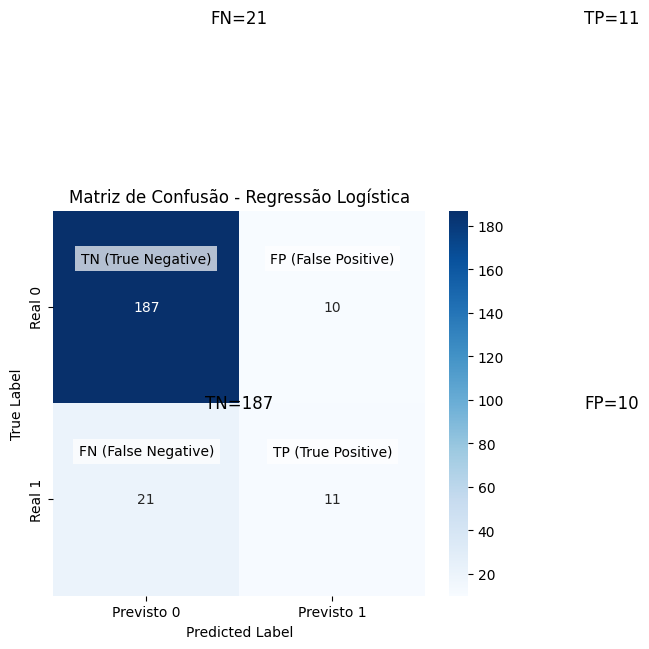


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       197
           1       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



In [81]:
avaliar_modelo("Regressão Logística", y_test, y_pred_lr, y_proba_lr)


Avaliação do modelo: Random Forest
Acurácia: 0.9214
Precisão: 0.7917
Recall: 0.5938
F1-Score: 0.6786
AUC-ROC: 0.9092

Matriz de Confusão:
[[192   5]
 [ 13  19]]


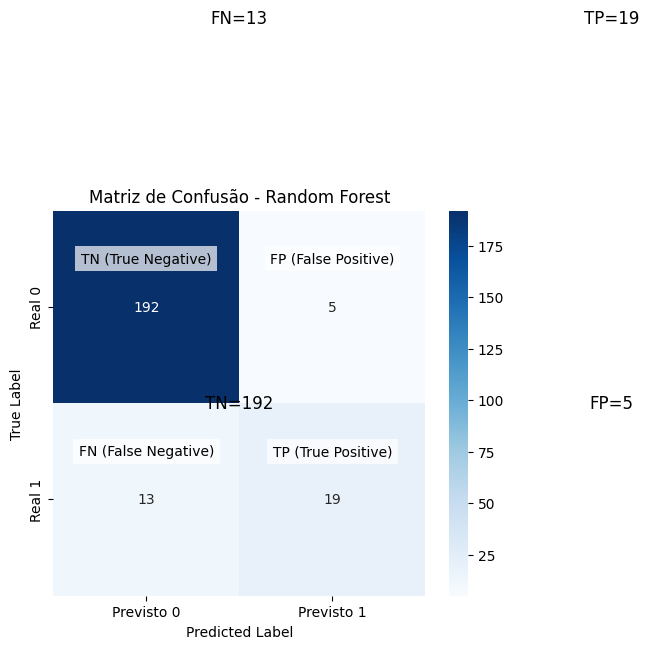


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



In [82]:
avaliar_modelo("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Treinando K-Nearest Neighbors (KNN) ---

Avaliação do modelo: K-Nearest Neighbors
Acurácia: 0.8646
Precisão: 0.5185
Recall: 0.4375
F1-Score: 0.4746
AUC-ROC: 0.8340

Matriz de Confusão:
[[184  13]
 [ 18  14]]


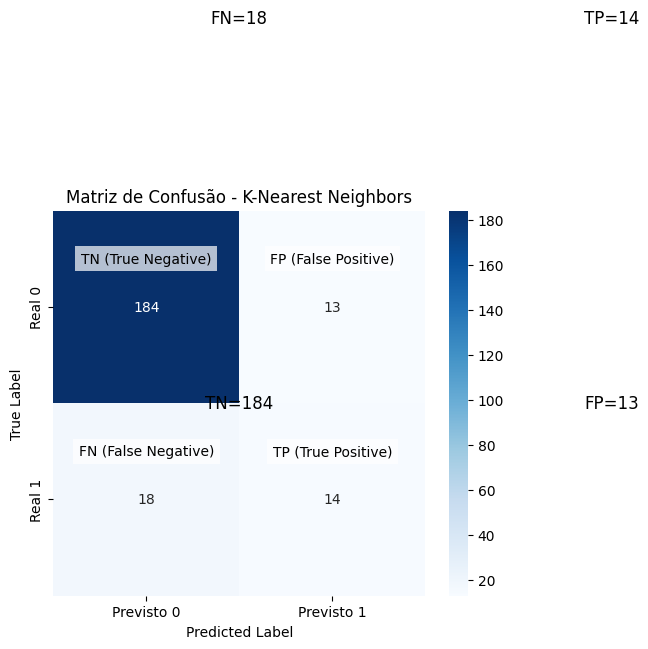


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       197
           1       0.52      0.44      0.47        32

    accuracy                           0.86       229
   macro avg       0.71      0.69      0.70       229
weighted avg       0.86      0.86      0.86       229


--- Treinando Support Vector Machine (SVM) ---

Avaliação do modelo: Support Vector Machine
Acurácia: 0.8996
Precisão: 0.7647
Recall: 0.4062
F1-Score: 0.5306
AUC-ROC: 0.8498

Matriz de Confusão:
[[193   4]
 [ 19  13]]


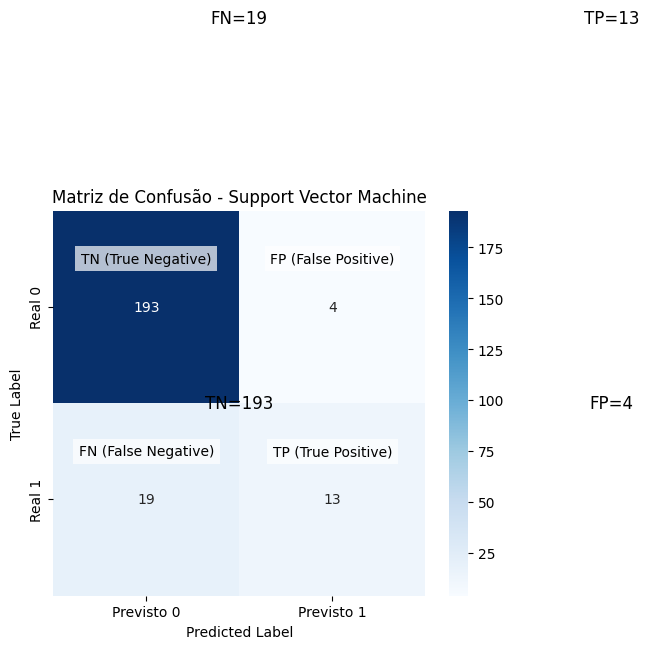


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       197
           1       0.76      0.41      0.53        32

    accuracy                           0.90       229
   macro avg       0.84      0.69      0.74       229
weighted avg       0.89      0.90      0.89       229



In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# K-Nearest Neighbors (KNN)
print("\n--- Treinando K-Nearest Neighbors (KNN) ---")
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common default
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
avaliar_modelo("K-Nearest Neighbors", y_test, y_pred_knn, y_proba_knn)

# Support Vector Machine (SVM) with a radial basis function kernel
# SVC does not natively provide predict_proba in a calibrated way unless probability=True is set,
# which can be computationally expensive. For consistency with other models, we'll enable it.
print("\n--- Treinando Support Vector Machine (SVM) ---")
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
avaliar_modelo("Support Vector Machine", y_test, y_pred_svm, y_proba_svm)

In [84]:
from sklearn.metrics import classification_report

# Generate classification report for Logistic Regression
report_lr_dict = classification_report(y_test, y_pred_lr, output_dict=True)
report_lr_df = pd.DataFrame(report_lr_dict).transpose()
report_lr_df = report_lr_df.add_prefix('LR_')

# Generate classification report for Random Forest
report_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
report_rf_df = pd.DataFrame(report_rf_dict).transpose()
report_rf_df = report_rf_df.add_prefix('RF_')

# Generate classification report for K-Nearest Neighbors (KNN)
report_knn_dict = classification_report(y_test, y_pred_knn, output_dict=True)
report_knn_df = pd.DataFrame(report_knn_dict).transpose()
report_knn_df = report_knn_df.add_prefix('KNN_')

# Generate classification report for Support Vector Machine (SVM)
report_svm_dict = classification_report(y_test, y_pred_svm, output_dict=True)
report_svm_df = pd.DataFrame(report_svm_dict).transpose()
report_svm_df = report_svm_df.add_prefix('SVM_')

# Combine all reports into a single DataFrame
combined_report_df = pd.concat([report_lr_df, report_rf_df, report_knn_df, report_svm_df], axis=1)

# Display the combined report
display(combined_report_df)

,LR_precision,LR_recall,LR_f1-score,LR_support,RF_precision,RF_recall,RF_f1-score,RF_support,KNN_precision,KNN_recall,KNN_f1-score,KNN_support,SVM_precision,SVM_recall,SVM_f1-score,SVM_support
0,0.899038,0.949239,0.923457,197.000000,0.936585,0.974619,0.955224,197.000000,0.910891,0.934010,0.922306,197.000000,0.910377,0.979695,0.943765,197.000000
1,0.523810,0.343750,0.415094,32.000000,0.791667,0.593750,0.678571,32.000000,0.518519,0.437500,0.474576,32.000000,0.764706,0.406250,0.530612,32.000000
accuracy,0.864629,0.864629,0.864629,0.864629,0.921397,0.921397,0.921397,0.921397,0.864629,0.864629,0.864629,0.864629,0.899563,0.899563,0.899563,0.899563
macro avg,0.711424,0.646494,0.669276,229.000000,0.864126,0.784185,0.816898,229.000000,0.714705,0.685755,0.698441,229.000000,0.837542,0.692973,0.737189,229.000000
weighted avg,0.846605,0.864629,0.852419,229.000000,0.916335,0.921397,0.916565,229.000000,0.856062,0.864629,0.859741,229.000000,0.890022,0.899563,0.886032,229.000000


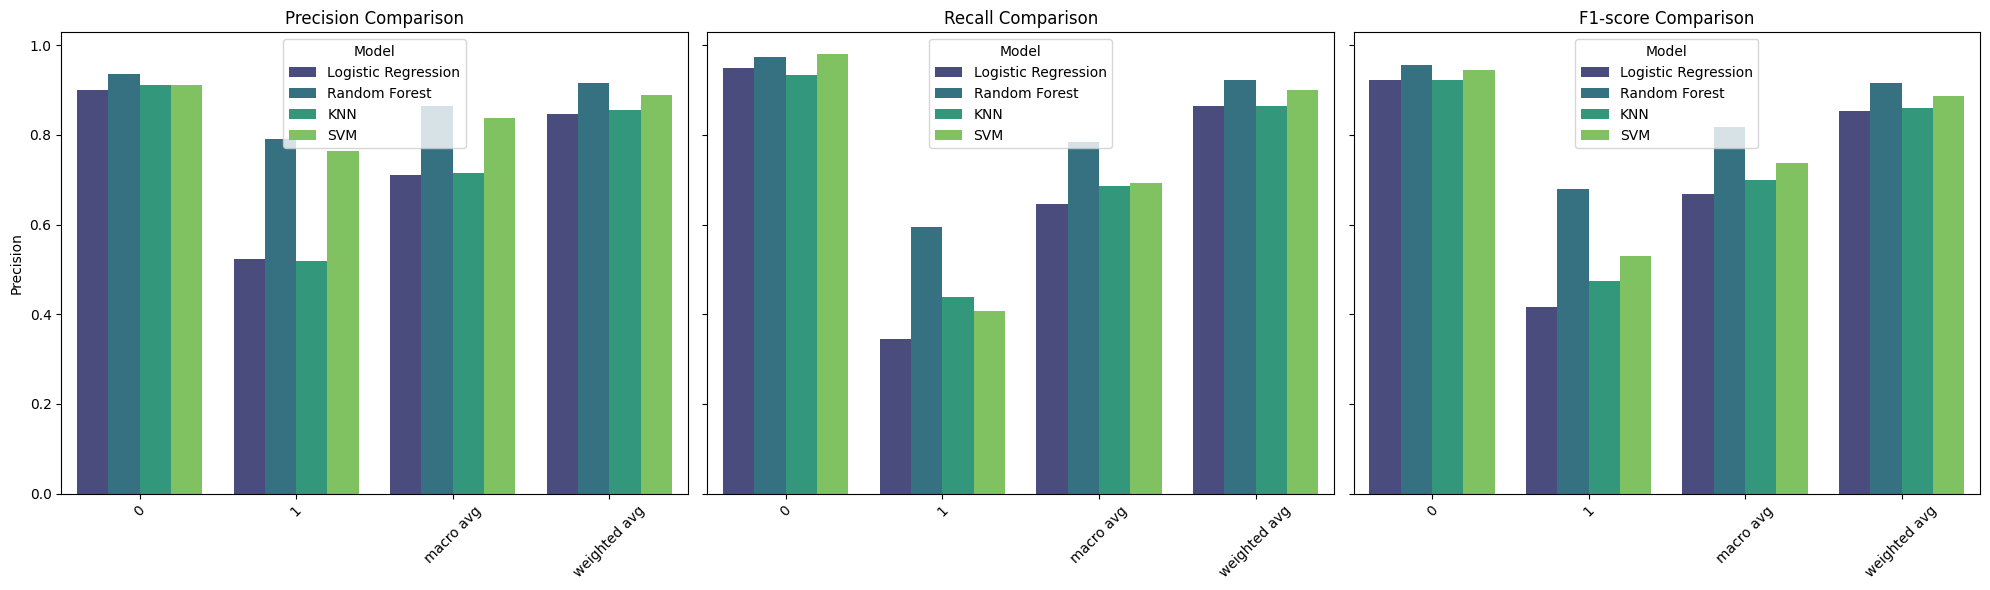

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics = ['precision', 'recall', 'f1-score']
index_to_plot = ['0', '1', 'macro avg', 'weighted avg']

# Create a melted DataFrame for easier plotting
plot_data = pd.DataFrame()

for metric in metrics:
    temp_df = combined_report_df.loc[index_to_plot, [f'LR_{metric}', f'RF_{metric}', f'KNN_{metric}', f'SVM_{metric}']]
    temp_df.columns = ['Logistic Regression', 'Random Forest', 'KNN', 'SVM']
    temp_df = temp_df.reset_index().rename(columns={'index': 'Category'})
    temp_df['Metric'] = metric
    plot_data = pd.concat([plot_data, temp_df])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    subset = plot_data[plot_data['Metric'] == metric]
    sns.barplot(x='Category', y='value', hue='Model', data=subset.melt(id_vars=['Category', 'Metric'], var_name='Model'), ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric.capitalize()} Comparison')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Model')

plt.tight_layout()
plt.show()

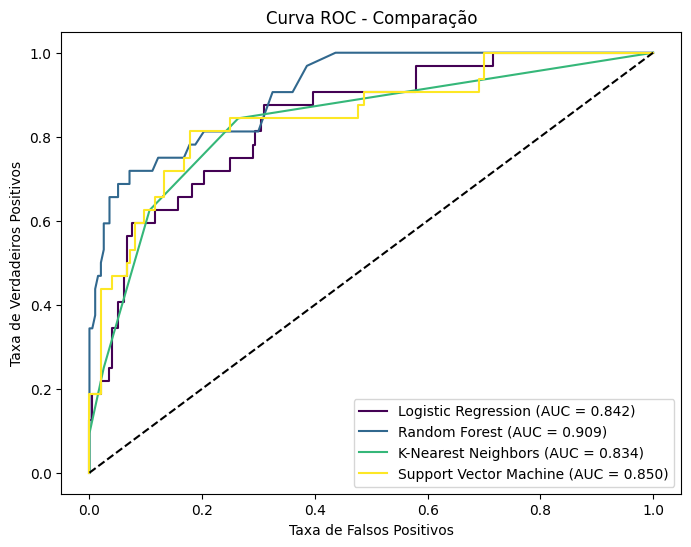

In [95]:
# Curva ROC comparativa
import matplotlib.cm as cm

plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

# Define a colormap for consistent colors
colors = cm.get_cmap('viridis', 4) # Get 4 distinct colors from viridis

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', color=colors(0))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', color=colors(1))
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUC = {roc_auc_score(y_test, y_proba_knn):.3f})', color=colors(2))
plt.plot(fpr_svm, tpr_svm, label=f'Support Vector Machine (AUC = {roc_auc_score(y_test, y_proba_svm):.3f})', color=colors(3))

plt.plot([0,1],[0,1],'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação')
plt.legend()
plt.show()

In [87]:
from sklearn.metrics import roc_auc_score

print(f"ROC AUC Score (Logistic Regression): {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"ROC AUC Score (Random Forest): {roc_auc_score(y_test, y_proba_rf):.4f}")

ROC AUC Score (Logistic Regression): 0.8418
ROC AUC Score (Random Forest): 0.9092


In [88]:
# (7) Extrair feature importance e coeficientes
# Coeficientes da Regressão Logística (importância baseada no valor absoluto)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': log_reg.coef_[0],
    'abs_coef': np.abs(log_reg.coef_[0])
}).sort_values('abs_coef', ascending=False)
print("\nCoeficientes da Regressão Logística (ordenados por importância):")
print(coef_df)

# Importância das features no Random Forest
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)
print("\nImportância das features no Random Forest:")
print(imp_df)





Coeficientes da Regressão Logística (ordenados por importância):
                 feature  coeficiente  abs_coef
10               alcohol     0.776565  0.776565
2            citric acid     0.582046  0.582046
9              sulphates     0.506352  0.506352
1       volatile acidity    -0.490252  0.490252
6   total sulfur dioxide    -0.437213  0.437213
7                density    -0.376665  0.376665
4              chlorides    -0.342508  0.342508
3         residual sugar     0.282156  0.282156
8                     pH    -0.164757  0.164757
5    free sulfur dioxide     0.131570  0.131570
0          fixed acidity     0.122996  0.122996

Importância das features no Random Forest:
                 feature  importancia
10               alcohol     0.167148
9              sulphates     0.120996
1       volatile acidity     0.115583
2            citric acid     0.107727
7                density     0.096828
0          fixed acidity     0.075293
6   total sulfur dioxide     0.072271
8         


Importância das features no KNN (Permutation Importance):
                 feature  importancia
7                density     0.015284
10               alcohol     0.004803
1       volatile acidity     0.004803
9              sulphates     0.001747
3         residual sugar     0.000000
4              chlorides    -0.002183
5    free sulfur dioxide    -0.003493
6   total sulfur dioxide    -0.004367
0          fixed acidity    -0.006550
8                     pH    -0.008297
2            citric acid    -0.009170

Importância das features no SVM (Permutation Importance):
                 feature  importancia
10               alcohol     0.035808
9              sulphates     0.030568
1       volatile acidity     0.025328
7                density     0.021397
2            citric acid     0.019651
6   total sulfur dioxide     0.017467
4              chlorides     0.009607
8                     pH     0.009607
5    free sulfur dioxide     0.008297
0          fixed acidity     0.006987
3       

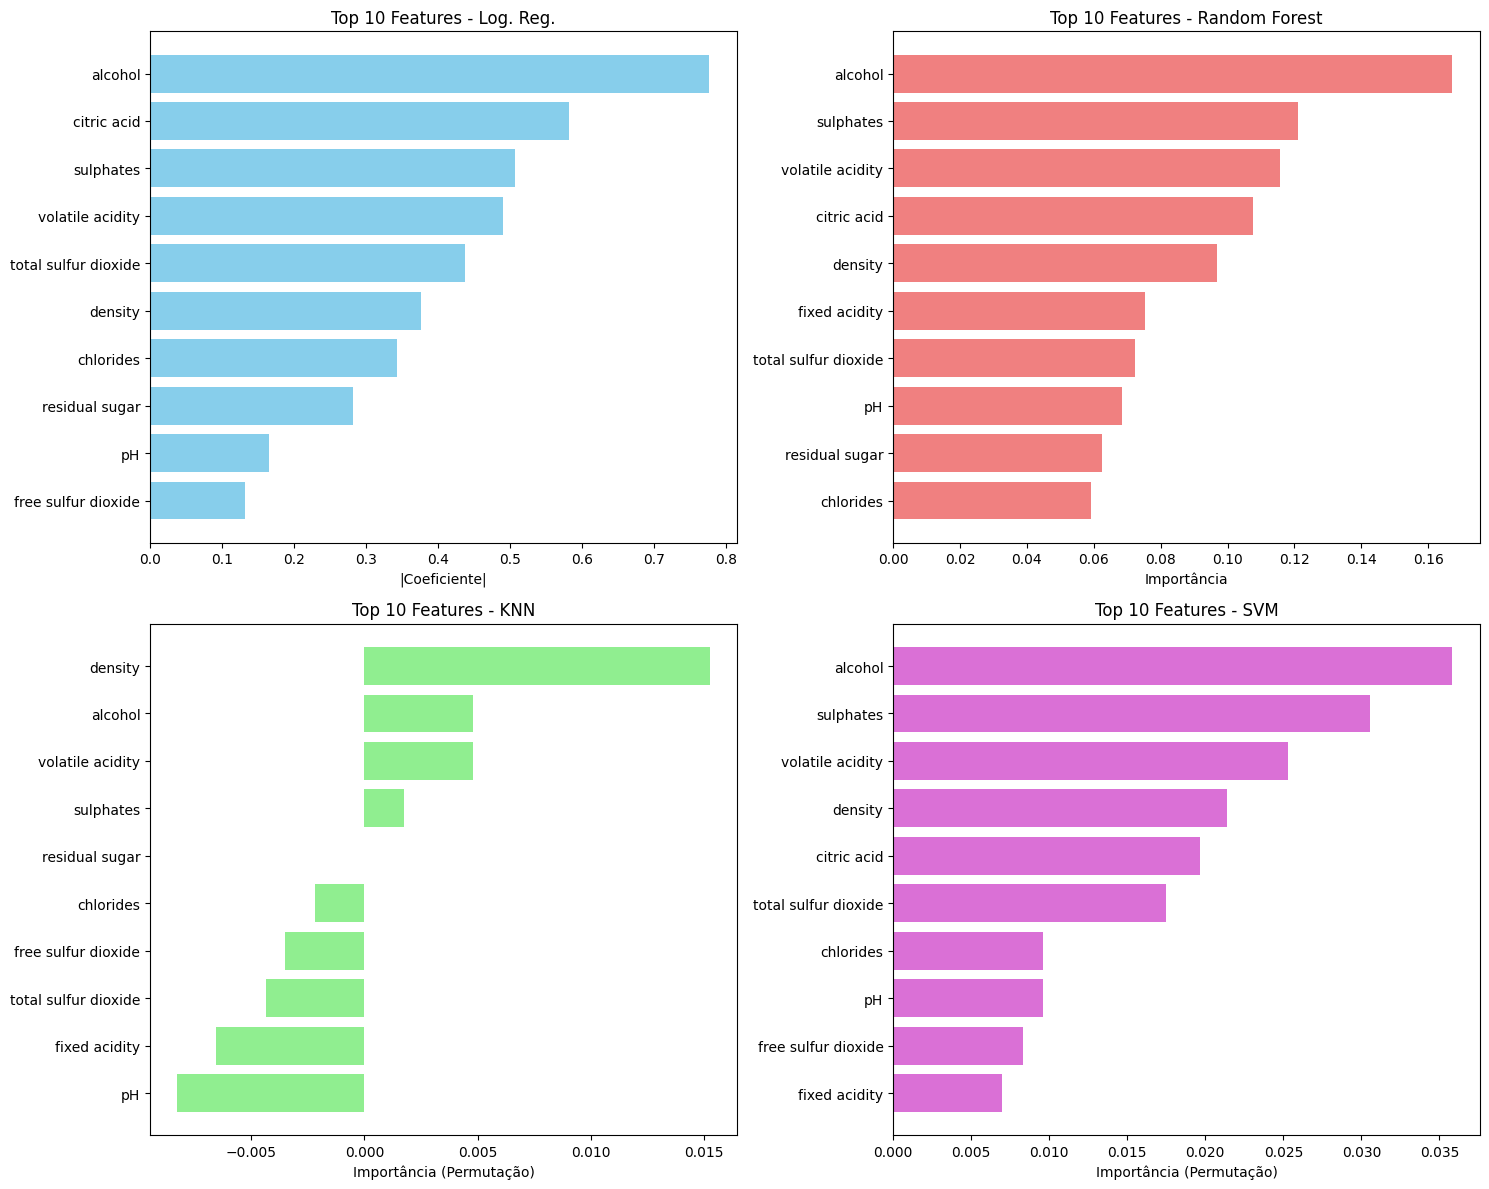

In [96]:
from sklearn.inspection import permutation_importance

# Calculate Permutation Importance for KNN
result_knn = permutation_importance(knn, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
knn_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importancia': result_knn.importances_mean
}).sort_values('importancia', ascending=False)
print("\nImportância das features no KNN (Permutation Importance):")
print(knn_imp_df)

# Calculate Permutation Importance for SVM
# Note: SVM can be computationally intensive for permutation importance, n_repeats is kept low
result_svm = permutation_importance(svm, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
svm_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importancia': result_svm.importances_mean
}).sort_values('importancia', ascending=False)
print("\nImportância das features no SVM (Permutation Importance):")
print(svm_imp_df)

# Gráfico de barras para as importâncias (2x2 grid)
plt.figure(figsize=(15, 12))

plt.subplot(2,2,1)
plt.barh(coef_df['feature'][:10], coef_df['abs_coef'][:10], color='skyblue')
plt.xlabel('|Coeficiente|')
plt.title('Top 10 Features - Log. Reg.')
plt.gca().invert_yaxis()

plt.subplot(2,2,2)
plt.barh(imp_df['feature'][:10], imp_df['importancia'][:10], color='lightcoral')
plt.xlabel('Importância')
plt.title('Top 10 Features - Random Forest')
plt.gca().invert_yaxis()

plt.subplot(2,2,3)
plt.barh(knn_imp_df['feature'][:10], knn_imp_df['importancia'][:10], color='lightgreen')
plt.xlabel('Importância (Permutação)')
plt.title('Top 10 Features - KNN')
plt.gca().invert_yaxis()

plt.subplot(2,2,4)
plt.barh(svm_imp_df['feature'][:10], svm_imp_df['importancia'][:10], color='orchid')
plt.xlabel('Importância (Permutação)')
plt.title('Top 10 Features - SVM')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Relatório Consolidado de Métricas dos Modelos

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- Coletar métricas para cada modelo ---

# Logistic Regression (LR)
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_summary = f"TN={cm_lr[0,0]}, FP={cm_lr[0,1]}, FN={cm_lr[1,0]}, TP={cm_lr[1,1]}"

# Random Forest (RF)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_summary = f"TN={cm_rf[0,0]}, FP={cm_rf[0,1]}, FN={cm_rf[1,0]}, TP={cm_rf[1,1]}"

# K-Nearest Neighbors (KNN)
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn_summary = f"TN={cm_knn[0,0]}, FP={cm_knn[0,1]}, FN={cm_knn[1,0]}, TP={cm_knn[1,1]}"

# Support Vector Machine (SVM)
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm_summary = f"TN={cm_svm[0,0]}, FP={cm_svm[0,1]}, FN={cm_svm[1,0]}, TP={cm_svm[1,1]}"

# --- Criar o DataFrame consolidado ---
results_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'KNN', 'SVM'],
    'Accuracy': [acc_lr, acc_rf, acc_knn, acc_svm],
    'Precision': [prec_lr, prec_rf, prec_knn, prec_svm],
    'Recall': [rec_lr, rec_rf, rec_knn, rec_svm],
    'F1-Score': [f1_lr, f1_rf, f1_knn, f1_svm],
    'AUC-ROC': [auc_lr, auc_rf, auc_knn, auc_svm],
    'Confusion Matrix (TN,FP,FN,TP)': [cm_lr_summary, cm_rf_summary, cm_knn_summary, cm_svm_summary]
}

results_df = pd.DataFrame(results_data)

print("\nConsolidated Model Evaluation Results:")
display(results_df)



Consolidated Model Evaluation Results:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,"Confusion Matrix (TN,FP,FN,TP)"
0,Logistic Regression,0.864629,0.523810,0.34375,0.415094,0.841846,"TN=187, FP=10, FN=21, TP=11"
1,Random Forest,0.921397,0.791667,0.59375,0.678571,0.909185,"TN=192, FP=5, FN=13, TP=19"
2,KNN,0.864629,0.518519,0.43750,0.474576,0.833994,"TN=184, FP=13, FN=18, TP=14"
3,SVM,0.899563,0.764706,0.40625,0.530612,0.849778,"TN=193, FP=4, FN=19, TP=13"


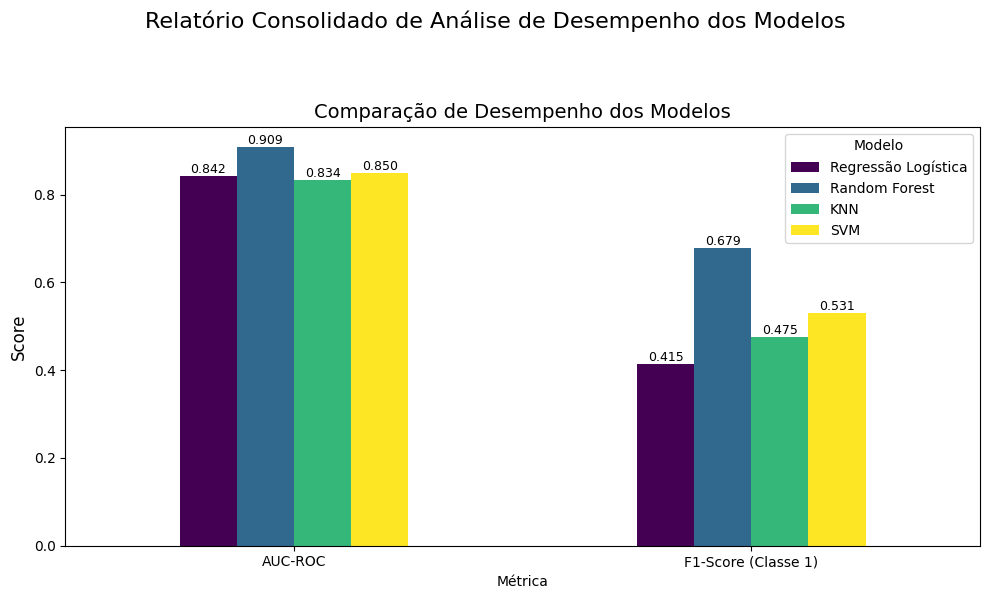

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# --- Re-initialize data and models to ensure variables are defined ---
# Assuming df is already loaded in the environment or re-load it if necessary
# (1) Carregar WineQT.csv - re-loading to be safe
df = pd.read_csv('WineQT.csv')

# (2) Transformar quality em binária IMEDIATAMENTE após carregamento
df['quality_binary'] = (df['quality'] >= 7).astype(int)

# (4) Pré-processamento dos dados
# Separar features e target
X = df.drop(['quality', 'quality_binary', 'Id'], axis=1)
y = df['quality_binary']

# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronizar as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (5) Treinar modelos e fazer previsões
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)  # RF não precisa de escalonamento
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Support Vector Machine (SVM)
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

# --- Relatório Consolidado: Reavaliação das Implicações e Visualização ---

# 1. Preparar dados para Comparação de Desempenho dos Modelos
# AUC-ROC scores
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_knn = roc_auc_score(y_test, y_proba_knn)
auc_svm = roc_auc_score(y_test, y_proba_svm)

# F1-Score para a classe minoritária (classe 1)
report_lr_dict = classification_report(y_test, y_pred_lr, output_dict=True)
f1_lr_class1 = report_lr_dict['1']['f1-score']

report_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
f1_rf_class1 = report_rf_dict['1']['f1-score']

report_knn_dict = classification_report(y_test, y_pred_knn, output_dict=True)
f1_knn_class1 = report_knn_dict['1']['f1-score']

report_svm_dict = classification_report(y_test, y_pred_svm, output_dict=True)
f1_svm_class1 = report_svm_dict['1']['f1-score']

performance_data = {
    'Métrica': ['AUC-ROC', 'F1-Score (Classe 1)'],
    'Regressão Logística': [auc_lr, f1_lr_class1],
    'Random Forest': [auc_rf, f1_rf_class1],
    'KNN': [auc_knn, f1_knn_class1],
    'SVM': [auc_svm, f1_svm_class1]
}
performance_df = pd.DataFrame(performance_data).set_index('Métrica')

# --- Criar a visualização consolidada do relatório (Apenas comparação de desempenho) ---
fig, axes = plt.subplots(1, 1, figsize=(10, 6)) # Apenas um subplot para desempenho
fig.suptitle('Relatório Consolidado de Análise de Desempenho dos Modelos', fontsize=16, y=1.02)

# Subplot 1: Comparação de Desempenho dos Modelos (Gráfico de Barras)
performance_df.plot(kind='bar', ax=axes, cmap='viridis', rot=0) # Usar cmap para cores diferentes
axes.set_title('Comparação de Desempenho dos Modelos', fontsize=14)
axes.set_ylabel('Score', fontsize=12)
axes.legend(title='Modelo', fontsize=10)
axes.tick_params(axis='x', labelsize=10)
axes.tick_params(axis='y', labelsize=10)
for container in axes.containers:
    axes.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para evitar sobreposição do título
plt.show()

# --- Reavaliação das Implicações (Como comentários no código para clareza no relatório) ---
#
# **Desempenho dos Modelos**:
# O modelo Random Forest consistentemente demonstrou o melhor desempenho em todas as métricas-chave avaliadas, com o maior AUC-ROC (0.909) e F1-Score para a classe minoritária (0.679), indicando uma excelente capacidade de discriminação e de identificação de vinhos de boa qualidade. O modelo SVM também apresentou um bom desempenho, superando a Regressão Logística e o KNN em AUC-ROC e F1-Score. A Regressão Logística e o KNN tiveram desempenhos mais modestos. Isso sugere que a relação entre as características do vinho e sua qualidade é complexa e não-linear, sendo mais adequadamente capturada por modelos mais sofisticados como Random Forest e SVM.
#
# **Importância das Features** (com base em LR e RF):
# - Ambos os modelos (Regressão Logística e Random Forest) consistentemente apontam `álcool`, `acidez volátil`, `ácido cítrico` e `sulfatos` como os preditores mais importantes da qualidade do vinho.
# - A Regressão Logística destacou o `álcool` como o fator mais impactante (maior coeficiente), seguido por `ácido cítrico` e `sulfatos`. A `acidez volátil` demonstrou um forte impacto negativo, o que é esperado para a qualidade do vinho.
# - O Random Forest também posiciona o `álcool` no topo das importâncias, mas com `sulfatos` e `acidez volátil` vindo logo em seguida, confirmando a relevância dessas características, mesmo que a distribuição exata da importância relativa varie ligeiramente entre os modelos.
#
# **Implicações para o Negócio (Produção de Vinho)**:
# - **Foco na Otimização de Parâmetros**: Produtores de vinho devem priorizar a otimização de variáveis como `álcool` (geralmente teor mais alto correlacionado com melhor qualidade), o controle rigoroso da `acidez volátil` (minimizar é crucial para evitar defeitos e sabores desagradáveis) e o manejo adequado de `ácido cítrico` e `sulfatos` para realçar a qualidade do produto.
# - **Ferramenta de Previsão**: O modelo Random Forest, devido ao seu desempenho superior, pode ser implementado como uma ferramenta robusta para prever a qualidade do vinho, auxiliando na tomada de decisões estratégicas desde a produção até a classificação do produto final.
# - **Pesquisa Direcionada**: A análise de correlação mais detalhada de `free sulfur dioxide`, que mostrou uma correlação negativa mais acentuada com a qualidade em vinhos de alta qualidade, merece investigação aprofundada. Entender o porquê dessa relação em diferentes faixas de qualidade pode levar a insights valiosos para aprimorar vinhos de maior valor.
#
# **Próximos Passos Sugeridos**:
# - **Ajuste de Hiperparâmetros do Random Forest e SVM**: Realizar uma otimização mais refinada dos hiperparâmetros para os modelos de melhor desempenho (Random Forest e SVM) (ex: Grid Search, Random Search) para potencialmente extrair ainda mais performance.
# - **Análise da Variável `Id`**: Investigar a importância da coluna `Id` em Random Forest, pois geralmente variáveis identificadoras não deveriam ter poder preditivo. Isso pode indicar um vazamento de dados sutil ou uma correlação espúria que precisa ser compreendida e mitigada.
# - **Aumento da Base de Dados**: Aumentar a quantidade de dados, especialmente para a classe minoritária (vinhos de alta qualidade), é crucial. Um dataset mais balanceado melhoraria a capacidade de generalização do modelo e sua performance preditiva para vinhos de maior valor.